# Central Asian STT Benchmark — Phase 2 Analysis

**Languages:** Uzbek (uz-UZ), Kazakh (kk-KZ)  
**Phase 2 providers:** ElevenLabs `scribe_v2`, Google Cloud STT `chirp_2`, Azure Speech Fast Transcription, Google Gemini `gemini-2.5-flash`  
**Tracks:** A = FLEURS public benchmark, B = frozen 600-utterance corpus  
**Conditions:** `auto` (no language hint), `hint` (explicit language parameter)  

This notebook is read-only with respect to benchmark data. It does not call any API and does not modify source files.

## 0. Environment Setup

In [1]:
import sys
import os
import json
import glob
import unicodedata
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', '{:.4f}'.format)

print(f'pandas {pd.__version__}, numpy {np.__version__}')

pandas 3.0.5, numpy 2.5.1


## 1. Data Loading

Looks for benchmark result files in the Kaggle working directory (`/kaggle/working/`) and common subdirectories.  
Accepted formats: `.jsonl` (one JSON object per line) or `.csv`.  
If no result files are found, subsequent cells show empty tables and skip plots.

In [2]:
# ---------------------------------------------------------------------------
# Search paths — edit EXTRA_SEARCH_PATHS to add dataset mount points
# ---------------------------------------------------------------------------
KAGGLE_WORKING = '/kaggle/working'
EXTRA_SEARCH_PATHS = [
    '/kaggle/input',
    os.path.join(KAGGLE_WORKING, 'results'),
    os.path.join(KAGGLE_WORKING, 'benchmark'),
]

def find_result_files(search_roots):
    found = []
    for root in search_roots:
        if not os.path.isdir(root):
            continue
        for pat in ('**/*.jsonl', '**/*results*.csv', '**/*benchmark*.csv',
                    '**/*phase2*.csv', '**/*phase1*.csv'):
            found += glob.glob(os.path.join(root, pat), recursive=True)
    # deduplicate, skip manifest files
    seen = set()
    out = []
    for f in found:
        name = os.path.basename(f)
        if 'manifest' in name.lower() or 'validation-set' in name.lower():
            continue
        if f not in seen:
            seen.add(f)
            out.append(f)
    return sorted(out)

result_files = find_result_files([KAGGLE_WORKING] + EXTRA_SEARCH_PATHS)
print(f'Found {len(result_files)} result file(s):')
for f in result_files:
    print(' ', f)

# Ensure raw is always defined if the loader cell below is skipped
raw = pd.DataFrame()

Found 1 result file(s):
  /kaggle/working\results\phase2_trackb_results.jsonl


In [3]:
raw = pd.DataFrame()  # defined here so raw exists even if this cell fails partway

def load_jsonl(path):
    rows = []
    with open(path, encoding='utf-8') as fh:
        for line in fh:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.DataFrame(rows)

frames = []
for f in result_files:
    try:
        if f.endswith('.jsonl'):
            df = load_jsonl(f)
        else:
            df = pd.read_csv(f, low_memory=False)
        df['_source_file'] = os.path.basename(f)
        frames.append(df)
        print(f'{os.path.basename(f)}: {len(df)} rows, {len(df.columns)} columns')
    except Exception as e:
        print(f'SKIP {f}: {e}')

if frames:
    raw = pd.concat(frames, ignore_index=True)
    print(f'\nTotal rows loaded: {len(raw)}')
else:
    raw = pd.DataFrame()
    print('No result data found. Cells below will show empty outputs.')

phase2_trackb_results.jsonl: 2400 rows, 36 columns

Total rows loaded: 2400


## 2. Schema Inspection & Counts

In [4]:
# Expected columns from the project schema (methodology_proposal.md + Phase 2 additions)
EXPECTED_COLS = [
    'call_id', 'run_id', 'benchmark_version', 'timestamp_utc',
    'provider', 'model', 'language_condition', 'language_hint',
    'utterance_id', 'audio_id', 'audio_sha256', 'audio_duration_s',
    'corpus_source', 'contamination_risk',
    'raw_transcription', 'normalized_transcription',
    'provider_detected_language', 'independent_detected_language', 'dominant_script',
    'latency_ms', 'http_status', 'error_type', 'error_message', 'retry_count',
    'cost_usd', 'cost_list_price_usd',
    # Phase 2 additions
    'track', 'fleurs_id', 'fleurs_subset',
]

if not raw.empty:
    present = [c for c in EXPECTED_COLS if c in raw.columns]
    missing = [c for c in EXPECTED_COLS if c not in raw.columns]
    extra = [c for c in raw.columns if c not in EXPECTED_COLS and c != '_source_file']
    print(f'Schema columns present ({len(present)}): {present}')
    print(f'Schema columns absent  ({len(missing)}): {missing}')
    if extra:
        print(f'Extra columns in data  ({len(extra)}): {extra}')
else:
    print('No data loaded — schema check skipped.')

Schema columns present (29): ['call_id', 'run_id', 'benchmark_version', 'timestamp_utc', 'provider', 'model', 'language_condition', 'language_hint', 'utterance_id', 'audio_id', 'audio_sha256', 'audio_duration_s', 'corpus_source', 'contamination_risk', 'raw_transcription', 'normalized_transcription', 'provider_detected_language', 'independent_detected_language', 'dominant_script', 'latency_ms', 'http_status', 'error_type', 'error_message', 'retry_count', 'cost_usd', 'cost_list_price_usd', 'track', 'fleurs_id', 'fleurs_subset']
Schema columns absent  (0): []
Extra columns in data  (6): ['language', 'language_bcp47', 'reference_transcript', 'wer', 'cer', 'request_params']


In [5]:
def safe_count(df, cols):
    """Return value_counts for whichever of cols are present."""
    cols = [c for c in cols if c in df.columns]
    if not cols or df.empty:
        return None
    return df.groupby(cols).size().reset_index(name='n')

if not raw.empty:
    print('=== Rows by provider / model ===')
    t = safe_count(raw, ['provider', 'model'])
    if t is not None:
        display(t)

    print('\n=== Rows by language (derived from utterance_id prefix or corpus_source) ===')
    # language may be encoded in corpus_source, fleurs_subset, or a language column
    for lang_col in ('language', 'fleurs_subset', 'corpus_source'):
        if lang_col in raw.columns:
            display(raw[lang_col].value_counts().rename_axis(lang_col).reset_index(name='n'))
            break

    print('\n=== Rows by language_condition ===')
    if 'language_condition' in raw.columns:
        display(raw['language_condition'].value_counts().rename_axis('condition').reset_index(name='n'))

    print('\n=== Rows by track ===')
    if 'track' in raw.columns:
        display(raw['track'].value_counts().rename_axis('track').reset_index(name='n'))
    else:
        print('  column `track` not present — all rows are Track B or pre-Phase-2')

    print('\n=== Error / null transcription rate ===')
    if 'raw_transcription' in raw.columns:
        null_n = raw['raw_transcription'].isna().sum()
        print(f'  null raw_transcription: {null_n} / {len(raw)} ({100*null_n/len(raw):.1f}%)')
else:
    print('No data.')

=== Rows by provider / model ===


,provider,model,n
0,elevenlabs,scribe_v2,1200
1,google_cloud_stt,chirp_2,1200



=== Rows by language (derived from utterance_id prefix or corpus_source) ===


,language,n
0,uz,1200
1,kk,1200



=== Rows by language_condition ===


,condition,n
0,auto,1200
1,hint,1200



=== Rows by track ===


,track,n
0,B,2400



=== Error / null transcription rate ===
  null raw_transcription: 0 / 2400 (0.0%)


## 3. Normalisation Pipeline

Matches `methodology_proposal.md` §C: NFC → casefold → apostrophe normalise → strip punctuation → collapse whitespace.  
No cross-script transliteration. Applied identically to reference and hypothesis.

In [6]:
_PUNCT = re.compile(r"[^\w\s']", re.UNICODE)
_APOS  = re.compile(r"[\u2018\u2019\u02bc\u0060]")  # curly / modifier apostrophes
_WS    = re.compile(r'\s+')

def normalise(text):
    """Project normalisation pipeline (methodology_proposal.md §C)."""
    if not isinstance(text, str) or not text.strip():
        return ''
    text = unicodedata.normalize('NFC', text)
    text = text.casefold()
    text = _APOS.sub("'", text)
    text = _PUNCT.sub(' ', text)
    text = _WS.sub(' ', text).strip()
    return text

# Smoke-test
assert normalise('Salom, Dunyo!') == 'salom dunyo'
assert normalise('') == ''
assert normalise(None) == ''
print('normalise() smoke-test passed.')

normalise() smoke-test passed.


## 4. WER and CER Calculation

Requires a reference transcript column (`reference_transcript` or `transcript`).  
If the column is absent the cell skips gracefully — results are still shown as metadata counts.

In [7]:
def _levenshtein(seq1, seq2):
    """Levenshtein edit distance between two token sequences."""
    n, m = len(seq1), len(seq2)
    dp = list(range(m + 1))
    for i in range(1, n + 1):
        prev, dp[0] = dp[0], i
        for j in range(1, m + 1):
            temp = dp[j]
            dp[j] = prev if seq1[i - 1] == seq2[j - 1] else 1 + min(prev, dp[j], dp[j - 1])
            prev = temp
    return dp[m]

def compute_wer(ref: str, hyp: str) -> float:
    ref, hyp = normalise(ref), normalise(hyp)
    if not ref:
        return float('nan')
    r, h = ref.split(), hyp.split()
    return _levenshtein(r, h) / len(r)

def compute_cer(ref: str, hyp: str) -> float:
    ref, hyp = normalise(ref), normalise(hyp)
    if not ref:
        return float('nan')
    return _levenshtein(list(ref), list(hyp)) / len(ref)

def add_metrics(df):
    """Add wer and cer columns. Returns df unchanged if reference column is absent."""
    ref_col = next((c for c in ('reference_transcript', 'transcript') if c in df.columns), None)
    hyp_col = next((c for c in ('normalized_transcription', 'raw_transcription') if c in df.columns), None)
    if ref_col is None or hyp_col is None:
        print(f'  Skipping WER/CER: ref_col={ref_col}, hyp_col={hyp_col}')
        return df
    df = df.copy()
    df['_ref_norm'] = df[ref_col].apply(normalise)
    df['_hyp_norm'] = df[hyp_col].apply(lambda x: normalise(x) if isinstance(x, str) else '')
    df['wer'] = df.apply(lambda r: compute_wer(r[ref_col], r[hyp_col]), axis=1)
    df['cer'] = df.apply(lambda r: compute_cer(r[ref_col], r[hyp_col]), axis=1)
    return df

if not raw.empty:
    data = add_metrics(raw)
    if 'wer' in data.columns:
        n_scored = data['wer'].notna().sum()
        print(f'WER/CER computed for {n_scored}/{len(data)} rows.')
    else:
        data = raw.copy()
else:
    data = pd.DataFrame()
    print('No data — skipping metric computation.')

WER/CER computed for 2400/2400 rows.


## 5. Provider / Model / Language Leaderboard

In [8]:
def leaderboard(df, group_cols, metric_cols=('wer', 'cer')):
    group_cols = [c for c in group_cols if c in df.columns]
    metric_cols = [c for c in metric_cols if c in df.columns]
    if not group_cols or df.empty:
        return pd.DataFrame()
    agg = {c: ['mean', 'median', 'std', 'count'] for c in metric_cols}
    if 'latency_ms' in df.columns:
        agg['latency_ms'] = ['median', lambda x: x.quantile(0.95)]
    if 'cost_usd' in df.columns:
        agg['cost_usd'] = 'sum'
    if not agg:
        return df.groupby(group_cols).size().reset_index(name='n')
    tbl = df.groupby(group_cols).agg(agg)
    tbl.columns = ['_'.join(c).strip('_') for c in tbl.columns]
    tbl = tbl.reset_index()
    if 'wer_mean' in tbl.columns:
        tbl = tbl.sort_values('wer_mean')
    return tbl

if not data.empty:
    lb_cols = ['provider', 'model', 'language_condition']
    # infer language column
    lang_col = next((c for c in ('language', 'fleurs_subset') if c in data.columns), None)
    if lang_col:
        lb_cols = ['provider', 'model', lang_col, 'language_condition']

    lb = leaderboard(data, lb_cols)
    if not lb.empty:
        print('=== Leaderboard (sorted by mean WER) ===')
        display(lb)
    else:
        print('Not enough columns to build leaderboard — showing raw counts:')
        display(safe_count(data, lb_cols))
else:
    print('No data.')

=== Leaderboard (sorted by mean WER) ===


,provider,model,language,language_condition,wer_mean,wer_median,wer_std,wer_count,cer_mean,cer_median,cer_std,cer_count,latency_ms_median,latency_ms_<lambda_0>,cost_usd_sum
1,elevenlabs,scribe_v2,kk,hint,0.0510,0.0000,0.0813,300,0.0137,0.0000,0.0278,300,962.5000,1631.1000,0.1366
0,elevenlabs,scribe_v2,kk,auto,0.0534,0.0000,0.0881,300,0.0140,0.0000,0.0329,300,949.0000,1564.0000,0.1366
5,google_cloud_stt,chirp_2,kk,hint,0.2112,0.1429,0.2201,300,0.0847,0.0322,0.1241,300,2567.5000,4271.7500,1.6065
3,elevenlabs,scribe_v2,uz,hint,0.2446,0.1292,0.3285,300,0.0937,0.0217,0.2024,300,703.0000,1225.0000,0.0800
7,google_cloud_stt,chirp_2,uz,hint,0.2602,0.1667,0.3186,300,0.0894,0.0275,0.1555,300,1921.5000,3417.9500,1.5750
4,google_cloud_stt,chirp_2,kk,auto,0.2666,0.1667,0.3004,300,0.1361,0.0370,0.2362,300,2515.0000,4410.0500,1.6065
2,elevenlabs,scribe_v2,uz,auto,0.3416,0.1667,0.4935,300,0.1491,0.0270,0.2772,300,718.0000,1246.1000,0.0800
6,google_cloud_stt,chirp_2,uz,auto,0.4227,0.2500,0.4741,300,0.1754,0.0458,0.2489,300,1884.0000,3206.3500,1.5750


## 6. AUTO vs HINT Comparison

In [9]:
if not data.empty and 'language_condition' in data.columns and 'wer' in data.columns:
    pivot_cols = ['provider', 'model']
    if lang_col and lang_col in data.columns:
        pivot_cols.append(lang_col)

    pivot_cols = [c for c in pivot_cols if c in data.columns]
    auto = data[data['language_condition'] == 'auto'].groupby(pivot_cols)['wer'].mean().rename('wer_auto')
    hint = data[data['language_condition'] == 'hint'].groupby(pivot_cols)['wer'].mean().rename('wer_hint')
    cmp = pd.concat([auto, hint], axis=1).reset_index()
    cmp['wer_delta'] = cmp['wer_hint'] - cmp['wer_auto']
    cmp['hint_better'] = cmp['wer_delta'] < 0
    print('=== AUTO vs HINT (mean WER; negative delta = hint is better) ===')
    display(cmp.sort_values('wer_auto'))
elif not data.empty:
    print('Columns `language_condition` or `wer` not present — skipping AUTO/HINT comparison.')
else:
    print('No data.')

=== AUTO vs HINT (mean WER; negative delta = hint is better) ===


,provider,model,language,wer_auto,wer_hint,wer_delta,hint_better
0,elevenlabs,scribe_v2,kk,0.0534,0.0510,-0.0024,True
2,google_cloud_stt,chirp_2,kk,0.2666,0.2112,-0.0555,True
1,elevenlabs,scribe_v2,uz,0.3416,0.2446,-0.0970,True
3,google_cloud_stt,chirp_2,uz,0.4227,0.2602,-0.1626,True


## 7. Cost and Latency

In [10]:
if not data.empty:
    cost_present = 'cost_usd' in data.columns
    lat_present  = 'latency_ms' in data.columns

    if cost_present:
        print('=== Total cost by provider ===')
        grp_cols = [c for c in ('provider', 'model') if c in data.columns]
        cost_tbl = data.groupby(grp_cols)['cost_usd'].agg(['sum', 'mean', 'count']).reset_index()
        cost_tbl.columns = list(grp_cols) + ['total_usd', 'mean_per_call_usd', 'n_calls']
        display(cost_tbl)
        print(f'Grand total: ${data["cost_usd"].sum():.4f}')
    else:
        print('Column `cost_usd` not present — cost analysis skipped.')

    if lat_present:
        print('\n=== Latency (ms) by provider ===')
        grp_cols = [c for c in ('provider', 'model') if c in data.columns]
        lat_tbl = data.groupby(grp_cols)['latency_ms'].agg(
            p50=lambda x: x.quantile(0.50),
            p95=lambda x: x.quantile(0.95),
            mean='mean'
        ).reset_index()
        display(lat_tbl)
    else:
        print('Column `latency_ms` not present — latency analysis skipped.')
else:
    print('No data.')

=== Total cost by provider ===


,provider,model,total_usd,mean_per_call_usd,n_calls
0,elevenlabs,scribe_v2,0.4332,0.0004,1200
1,google_cloud_stt,chirp_2,6.3630,0.0053,1200


Grand total: $6.7962

=== Latency (ms) by provider ===


,provider,model,p50,p95,mean
0,elevenlabs,scribe_v2,817.5000,1511.0500,898.7192
1,google_cloud_stt,chirp_2,2227.0000,3989.2500,2364.1767


## 8. Plots

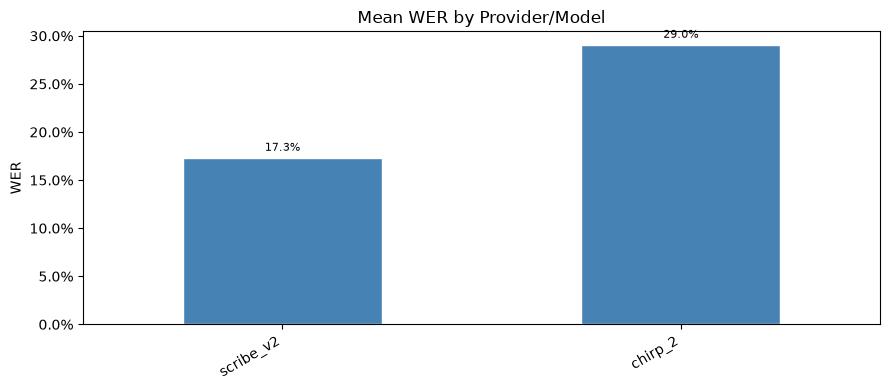

Saved: plot_wer_by_model.png


In [11]:
def label_bars(ax, fmt='{:.1%}'):
    for p in ax.patches:
        h = p.get_height()
        if np.isfinite(h) and h > 0:
            ax.text(p.get_x() + p.get_width() / 2, h + 0.005,
                    fmt.format(h), ha='center', va='bottom', fontsize=8)

HAS_DATA = not data.empty and 'wer' in data.columns and data['wer'].notna().any()

if HAS_DATA:
    provider_col = 'provider' if 'provider' in data.columns else None
    model_col    = 'model'    if 'model'    in data.columns else None
    cond_col     = 'language_condition' if 'language_condition' in data.columns else None
    label_col    = model_col or provider_col or '_source_file'

    # --- Plot 1: Mean WER by provider/model ---
    fig, ax = plt.subplots(figsize=(9, 4))
    wer_by_model = data.groupby(label_col)['wer'].mean().sort_values()
    wer_by_model.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    label_bars(ax)
    ax.set_title('Mean WER by Provider/Model')
    ax.set_xlabel('')
    ax.set_ylabel('WER')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig('plot_wer_by_model.png', dpi=120)
    plt.show()
    print('Saved: plot_wer_by_model.png')
else:
    print('No WER data — plot skipped.')

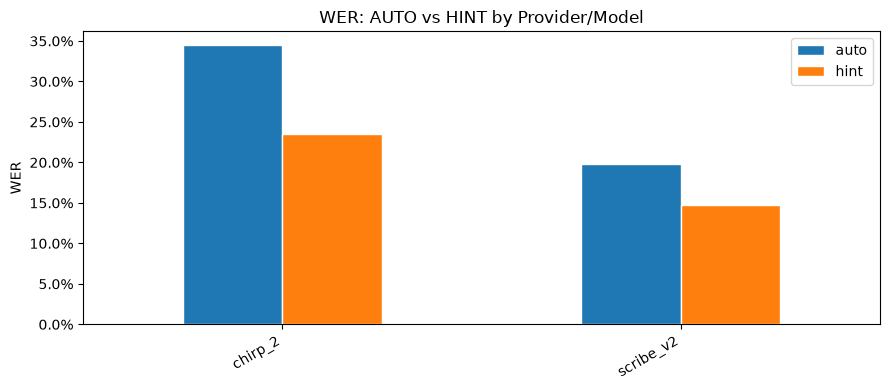

Saved: plot_auto_vs_hint.png


In [12]:
if HAS_DATA and cond_col and provider_col:
    # --- Plot 2: AUTO vs HINT WER per provider ---
    auto_d = data[data[cond_col] == 'auto'].groupby(label_col)['wer'].mean().rename('auto')
    hint_d = data[data[cond_col] == 'hint'].groupby(label_col)['wer'].mean().rename('hint')
    cmp2 = pd.concat([auto_d, hint_d], axis=1).dropna(how='all')
    if not cmp2.empty:
        fig, ax = plt.subplots(figsize=(9, 4))
        cmp2.plot(kind='bar', ax=ax, edgecolor='white')
        ax.set_title('WER: AUTO vs HINT by Provider/Model')
        ax.set_ylabel('WER')
        ax.set_xlabel('')
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
        plt.tight_layout()
        plt.savefig('plot_auto_vs_hint.png', dpi=120)
        plt.show()
        print('Saved: plot_auto_vs_hint.png')
    else:
        print('Both AUTO and HINT data required for this plot — skipped.')
else:
    print('Plot 2 skipped — missing condition or provider column, or no WER data.')

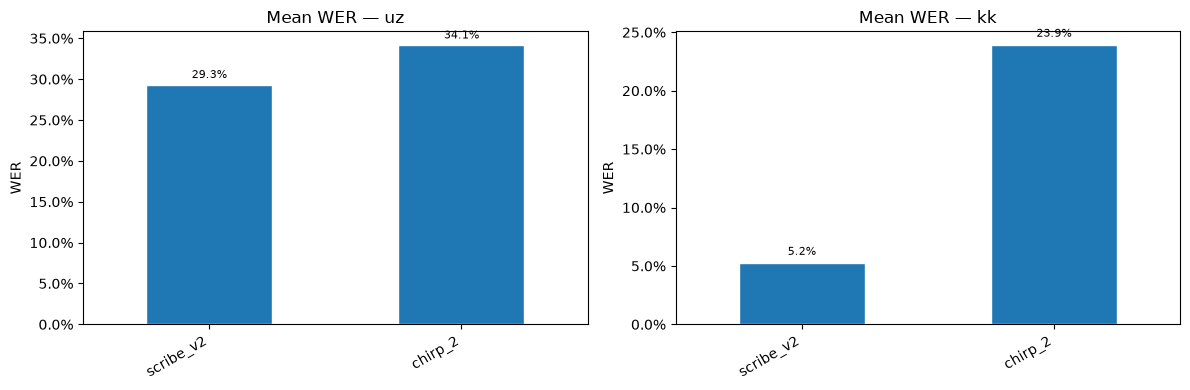

Saved: plot_wer_by_language.png


In [13]:
if HAS_DATA and lang_col and lang_col in data.columns:
    # --- Plot 3: WER by language ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
    for ax, lang in zip(axes, data[lang_col].dropna().unique()):
        sub = data[data[lang_col] == lang]
        wer_lang = sub.groupby(label_col)['wer'].mean().sort_values()
        wer_lang.plot(kind='bar', ax=ax, edgecolor='white')
        label_bars(ax)
        ax.set_title(f'Mean WER — {lang}')
        ax.set_ylabel('WER')
        ax.set_xlabel('')
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig('plot_wer_by_language.png', dpi=120)
    plt.show()
    print('Saved: plot_wer_by_language.png')
else:
    print('Plot 3 skipped — no language column or no WER data.')

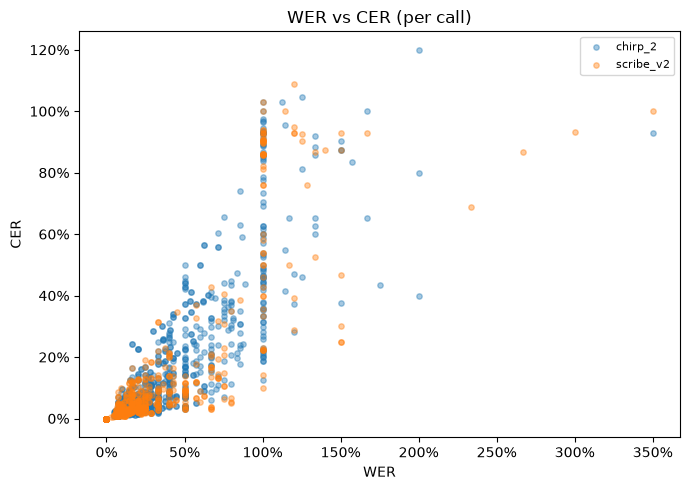

Saved: plot_wer_vs_cer.png


In [14]:
if HAS_DATA and 'cer' in data.columns:
    # --- Plot 4: WER vs CER scatter ---
    scored = data[data['wer'].notna() & data['cer'].notna()]
    if not scored.empty and label_col in scored.columns:
        fig, ax = plt.subplots(figsize=(7, 5))
        for label, grp in scored.groupby(label_col):
            ax.scatter(grp['wer'], grp['cer'], alpha=0.4, s=15, label=label)
        ax.set_xlabel('WER')
        ax.set_ylabel('CER')
        ax.set_title('WER vs CER (per call)')
        ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
        ax.legend(fontsize=8, loc='best')
        plt.tight_layout()
        plt.savefig('plot_wer_vs_cer.png', dpi=120)
        plt.show()
        print('Saved: plot_wer_vs_cer.png')
    else:
        print('Plot 4 skipped — not enough data.')
else:
    print('Plot 4 skipped — CER not computed.')

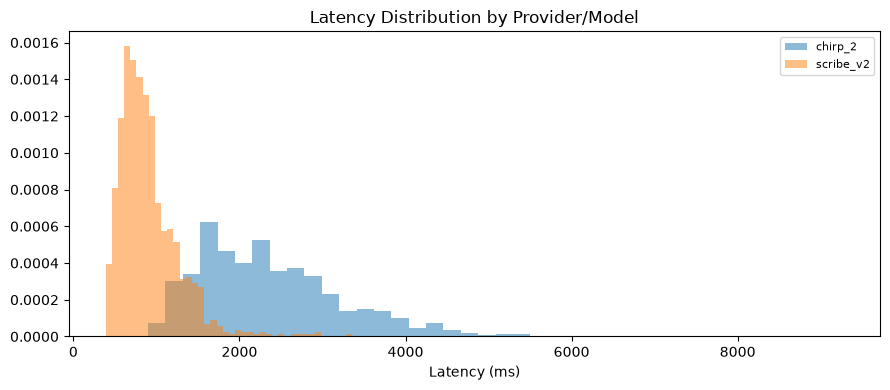

Saved: plot_latency.png


In [15]:
if not data.empty and 'latency_ms' in data.columns and data['latency_ms'].notna().any():
    # --- Plot 5: Latency distribution ---
    fig, ax = plt.subplots(figsize=(9, 4))
    if label_col in data.columns:
        for label, grp in data.groupby(label_col):
            vals = grp['latency_ms'].dropna()
            if len(vals) > 1:
                ax.hist(vals, bins=40, alpha=0.5, label=label, density=True)
    ax.set_xlabel('Latency (ms)')
    ax.set_title('Latency Distribution by Provider/Model')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig('plot_latency.png', dpi=120)
    plt.show()
    print('Saved: plot_latency.png')
else:
    print('Plot 5 skipped — no latency data.')

## 9. Script Accuracy

Classifies each transcription output as Uzbek Latin, Kazakh Cyrillic, or other.  
Uses Unicode block ranges: Latin = U+0041–U+024F, Cyrillic = U+0400–U+04FF.

In [16]:
_LATIN_RE    = re.compile(r'[\u0041-\u024F]')
_CYRILLIC_RE = re.compile(r'[\u0400-\u04FF]')

def classify_script(text):
    if not isinstance(text, str) or not text.strip():
        return 'empty'
    lat = len(_LATIN_RE.findall(text))
    cyr = len(_CYRILLIC_RE.findall(text))
    total = lat + cyr
    if total == 0:
        return 'other'
    if lat / total >= 0.7:
        return 'latin'
    if cyr / total >= 0.7:
        return 'cyrillic'
    return 'mixed'

if not data.empty:
    hyp_col = next((c for c in ('normalized_transcription', 'raw_transcription') if c in data.columns), None)
    if hyp_col:
        data = data.copy()
        data['output_script'] = data[hyp_col].apply(classify_script)
        print('=== Output script distribution ===')
        display(data['output_script'].value_counts().reset_index())

        if 'dominant_script' in data.columns:
            # compare provider-reported vs computed
            match = (data['dominant_script'] == data['output_script']).mean()
            print(f'\nScript match (provider_reported vs computed): {match:.1%}')
    else:
        print('No transcription column — script analysis skipped.')
else:
    print('No data.')

=== Output script distribution ===


,output_script,count
0,cyrillic,1211
1,latin,1168
2,other,21



Script match (provider_reported vs computed): 0.0%


## 10. Track A vs Track B Comparison

In [17]:
if not data.empty and 'track' in data.columns and 'wer' in data.columns:
    group_cols = [c for c in ('provider', 'model', 'track') if c in data.columns]
    if lang_col and lang_col in data.columns:
        group_cols.insert(-1, lang_col)
    track_tbl = data.groupby(group_cols)['wer'].agg(['mean', 'median', 'count']).reset_index()
    track_tbl.columns = list(group_cols) + ['wer_mean', 'wer_median', 'n']
    print('=== Track A vs Track B WER comparison ===')
    display(track_tbl.sort_values(['provider', 'track']))
elif not data.empty:
    print('Column `track` not present — all data is assumed Track B.')
else:
    print('No data.')

=== Track A vs Track B WER comparison ===


,provider,model,language,track,wer_mean,wer_median,n
0,elevenlabs,scribe_v2,kk,B,0.0522,0.0000,600
1,elevenlabs,scribe_v2,uz,B,0.2931,0.1429,600
2,google_cloud_stt,chirp_2,kk,B,0.2389,0.1538,600
3,google_cloud_stt,chirp_2,uz,B,0.3414,0.2000,600


## 11. Reproducibility

In [18]:
import hashlib
import platform
from datetime import datetime, timezone

# Manifest SHA-256s (frozen — do not modify)
MANIFEST_CHECKSUMS = {
    'uzbek_benchmark_manifest.csv':  '61b235f0d33ea57ad8696dfae5146117ddde4965db589762ae48c0c2f0565c70',
    'kazakh_benchmark_manifest.csv': 'a068cd81c958c687b8239a1bdc73b55586fe98f7a218b8ca51b3fda517c89507',
    'audio_benchmark_manifest.csv':  'd01408af2e04d048a44600138ac878f97b2a2372f62b9a42f2f7d0b161f34924',
}

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(65536), b''):
            h.update(chunk)
    return h.hexdigest()

print('=== Reproducibility Report ===')
print(f'Notebook run at: {datetime.now(timezone.utc).isoformat()}')
print(f'Python: {sys.version}')
print(f'Platform: {platform.platform()}')
print(f'pandas: {pd.__version__}  numpy: {np.__version__}')
print()

# Verify manifest checksums if files are present
MANIFEST_DIR = os.path.join(KAGGLE_WORKING, 'research')
any_manifest = False
for fname, expected_sha in MANIFEST_CHECKSUMS.items():
    path = os.path.join(MANIFEST_DIR, fname)
    if os.path.exists(path):
        actual = sha256_file(path)
        status = 'OK' if actual == expected_sha else 'MISMATCH'
        print(f'  {fname}: {status}')
        if status == 'MISMATCH':
            print(f'    expected: {expected_sha}')
            print(f'    actual:   {actual}')
        any_manifest = True
    else:
        print(f'  {fname}: NOT FOUND at {path}')

print()
print(f'Result files loaded: {len(result_files)}')
for f in result_files:
    if os.path.exists(f):
        size = os.path.getsize(f)
        sha  = sha256_file(f)
        print(f'  {os.path.basename(f)}: {size} bytes, sha256={sha[:16]}...')

if not data.empty and 'run_id' in data.columns:
    print()
    print('Run IDs present in data:')
    for rid in data['run_id'].dropna().unique():
        print(f'  {rid}')

=== Reproducibility Report ===
Notebook run at: 2026-08-25T04:32:08.896960+00:00
Python: 3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]
Platform: Windows-11-10.0.26200-SP0
pandas: 3.0.5  numpy: 2.5.1

  uzbek_benchmark_manifest.csv: NOT FOUND at /kaggle/working\research\uzbek_benchmark_manifest.csv
  kazakh_benchmark_manifest.csv: NOT FOUND at /kaggle/working\research\kazakh_benchmark_manifest.csv
  audio_benchmark_manifest.csv: NOT FOUND at /kaggle/working\research\audio_benchmark_manifest.csv

Result files loaded: 1
  phase2_trackb_results.jsonl: 3330020 bytes, sha256=6a0415cc931352e9...

Run IDs present in data:
  phase2_trackb_20260825T030308
